In [ ]:
pip install pandas numpy scikit-learn factor_analyzer xgboost shap statsmodels matplotlib seaborn joblib pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score, confusion_matrix
import shap

There are 49 fields in the dataset. I will use factor analyser and chi_square values to select the top numerical and categorical variable

Import data from google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = '/content/drive/My Drive/Data Science Projects/customer_churn_cleaned_data.csv'
df = pd.read_csv(file_path)

print(df.head())


   customer_id        full_name  age age_group  gender        state  \
0      1444270  Customer 444269   27     26-35    Male    Karnataka   
1      1029696   Customer 29695   43     35-50   Other    Telangana   
2      1050871   Customer 50870   24     18-25    Male      Gujarat   
3      1340336  Customer 340335   59       50+  Female  West Bengal   
4      1137281  Customer 137280   54       50+    Male    Telangana   

  signup_date  tenure_months  tenure_group membership_tier  ...  \
0  2018-08-04            100  Over 3 years          Silver  ...   
1  2018-09-23            104  Over 3 years          Silver  ...   
2  2022-12-16             89  Over 3 years           Basic  ...   
3  2025-02-05            107  Over 3 years          Silver  ...   
4  2021-02-11             33       3 years            Gold  ...   

  days_since_last_login days_since_last_login_group email_open_rate  \
0                     0                  Over 1year            0.33   
1                     0     

Feature selection for numerical features

In [12]:
df_numeric =df[['total_orders','total_spent','total_returns','lifetime_value','churn_risk_score',
 'payment_failures','average_monthly_spend','cart_abandon_rate',
 'email_open_rate','tickets_last_year','avg_resolution_hours','age', 'wishlist_items', 'tenure_months','sales', 'subscription_fee','Order_year']]



In [13]:
#Feature selection for numerical_features
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler

# Scale the numerical data
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_numeric)

# Initialize and fit FactorAnalyzer with 5 factors
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='ml') # 'varimax' for orthogonal rotation
fa.fit(numeric_scaled)

# Get loadings
loadings = pd.DataFrame(fa.loadings_, index=df_numeric.columns, columns=[f'Factor{i+1}' for i in range(5)])
print("Factor loadings:\n", loadings.round(3))

# Communalities (how much variance each variable explains)
communalities = pd.Series(fa.get_communalities(), index=df_numeric.columns)
print("\nCommunalities:\n", communalities.round(3))

# Select variables with strong loadings (absolute value > 0.4 on any factor)
selected_vars = loadings[loadings.abs().max(axis=1) > 0.5].index.tolist()
print("\nVariables chosen by factor analysis (|loading| > 0.5):\n")
print(selected_vars)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Factor loadings:
                        Factor1  Factor2  Factor3  Factor4  Factor5
total_orders             0.748    0.079    0.578    0.047   -0.183
total_spent              0.983    0.029   -0.079   -0.149    0.010
total_returns            0.030    0.969    0.012   -0.088    0.025
lifetime_value           0.940    0.020    0.002   -0.116    0.308
churn_risk_score        -0.327    0.145   -0.288   -0.049    0.095
payment_failures         0.002   -0.002    0.005   -0.014    0.004
average_monthly_spend    0.001    0.002   -0.000   -0.005   -0.001
cart_abandon_rate       -0.003   -0.001   -0.009    0.005   -0.001
email_open_rate         -0.004   -0.001    0.000   -0.003   -0.004
tickets_last_year        0.001    0.006   -0.008    0.032    0.005
avg_resolution_hours     0.000    0.001   -0.003    0.034   -0.002
age                      0.003   -0.003   -0.001   -0.008   -0.003
wishlist_items          -0.000   -0.002   -0.008    0.012    0.002
tenure_months            0.000    0.003   -0

Categorical feature selection

In [6]:
# handling date columns
df['signup_date'] = pd.to_datetime(df['signup_date'])

df['order_date'] = pd.to_datetime(df['order_date'])

df['signup_year'] = df['signup_date'].dt.year.astype(str)

df['order_date'] = df['order_date'].dt.year.astype(str)

df_dates = df[['signup_year', 'order_date']]
df_dates.head()

,signup_year,order_date
0,2018,2022
1,2018,2023
2,2022,2025
3,2025,2021
4,2021,2020


In [7]:
df_category= df[['age_group',
'product_category', 'payment_method',
'customer_segment',
'gender',
'state',
'tenure_group',
'membership_tier',
'income_group',
'preferred_device',
'delivery_days',
'order_status',
'return_reason',
'payment_status',
'days_since_last_login_group',
'avg_resolution_group',
'escalated',
'issue_status',
'subscription_active'
                      ]]

df_string_with_date = pd.concat([df_dates, df_category], axis=1)

df_string_with_date.head()

,signup_year,order_date,age_group,product_category,payment_method,customer_segment,gender,state,tenure_group,membership_tier,...,preferred_device,delivery_days,order_status,return_reason,payment_status,days_since_last_login_group,avg_resolution_group,escalated,issue_status,subscription_active
0,2018,2022,26-35,Electronics,Debit Card,At Risk,Male,Karnataka,Over 3 years,Silver,...,iPhone,1,Delivered,Unknown,Pending,Over 1year,1 day,True,Closed,True
1,2018,2023,35-50,Electronics,Wallet,New,Other,Telangana,Over 3 years,Silver,...,iPhone,4,Returned,Late Delivery,Refunded,Over 1year,1 day,False,Closed,False
2,2022,2025,18-25,Grocery,Wallet,New,Male,Gujarat,Over 3 years,Basic,...,iPhone,10,Delivered,Unknown,Success,Over 1year,2 days,True,Open,False
3,2025,2021,50+,Home,COD,New,Female,West Bengal,Over 3 years,Silver,...,Android,1,Delivered,Unknown,Success,Over 1year,2 days,True,Escalated,True
4,2021,2020,50+,Home,UPI,At Risk,Male,Telangana,3 years,Gold,...,iPhone,7,Returned,Changed Mind,Success,Over 1year,2 days,True,Escalated,True


In [14]:
# Feature selection for categorical columns with chi-square p-values
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Use all columns from df_string_with_date as categorical features
cat_cols = df_string_with_date.columns.tolist()

# Encode categorical columns into integers
df_encoded = df_string_with_date.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Define X (categorical features) and y (target churn from main df)
X_cat = df_encoded[cat_cols]
y = df['churn'].astype(int)   # assumes df has the churn column

# Apply chi-square feature selection
selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_cat, y)

# Collect scores and p-values
scores = selector.scores_
pvalues = selector.pvalues_

results = pd.DataFrame({
    'feature': cat_cols,
    'chi2_score': scores,
    'p_value': pvalues
}).sort_values('p_value')

print("Chi-square test results for categorical features:")
print(results)


Chi-square test results for categorical features:
                        feature    chi2_score   p_value
5              customer_segment  15219.723467  0.000000
7                         state      7.965958  0.004767
1                    order_date      1.441919  0.229829
18                    escalated      1.350202  0.245243
20          subscription_active      1.256982  0.262223
9               membership_tier      1.104977  0.293176
19                 issue_status      1.021510  0.312161
17         avg_resolution_group      0.695076  0.404443
16  days_since_last_login_group      0.313617  0.575469
14                return_reason      0.298425  0.584871
2                     age_group      0.257046  0.612157
4                payment_method      0.238864  0.625027
13                 order_status      0.112353  0.737481
0                   signup_year      0.074217  0.785294
15               payment_status      0.060876  0.805116
3              product_category      0.051936  0.81972

Feature engineering

In [26]:
best_five_numerical_features = df_numeric[[ 'total_orders','total_spent','total_returns','lifetime_value']]
best_categorical_features = df_string_with_date[['state','customer_segment' ]]
best_categorical_features_encoded = pd.get_dummies(best_categorical_features, drop_first=True)
Ml_data_X= pd.concat([best_five_numerical_features, best_categorical_features_encoded], axis=1)
Ml_data_X.head()

,total_orders,total_spent,total_returns,lifetime_value,state_Gujarat,state_Haryana,state_Karnataka,state_Maharashtra,state_Tamil Nadu,state_Telangana,state_West Bengal,customer_segment_High Value,customer_segment_Loyal,customer_segment_New,customer_segment_Occasional
0,1,900.28,0,2250.41,False,False,True,False,False,False,False,False,False,False,False
1,3,2581.20,3,3439.84,False,False,False,False,False,True,False,False,False,True,False
2,7,3507.56,5,6828.28,True,False,False,False,False,False,False,False,False,True,False
3,4,3840.80,4,5152.49,False,False,False,False,False,False,True,False,False,True,False
4,2,5675.58,1,10550.27,False,False,False,False,False,True,False,False,False,False,False


Dependent varaible

In [16]:
Ml_data_y = df['churn']
Ml_data_y.head()

,churn
0,True
1,True
2,True
3,True
4,True


CUSTOMER CHURN PREDICTION

Model training

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Ml_data_X, Ml_data_y, test_size=0.3, random_state=0)
print(len(X_train))
print(len(X_test))


79438
34046


Logistic Model

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(solver='lbfgs', max_iter=1000))
])

pipeline.fit(X_train, y_train)
logistic_Model_pred = pipeline.predict(X_test)

In [29]:
# printing classification model
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap
print(classification_report(y_test, logistic_Model_pred))
print (confusion_matrix(y_test, logistic_Model_pred))

              precision    recall  f1-score   support

       False       0.90      0.96      0.92     26918
        True       0.77      0.58      0.66      7128

    accuracy                           0.88     34046
   macro avg       0.84      0.77      0.79     34046
weighted avg       0.87      0.88      0.87     34046

[[25713  1205]
 [ 2981  4147]]


Xgboost model

In [49]:
import xgboost as xgb

xgboost_model = xgb.XGBClassifier(n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
).fit(X_train,y_train)

# Predict with a model
xgboost_preds = xgboost_model.predict(X_test)
xgboost_probs = xgboost_model.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, xgboost_preds))
print(confusion_matrix(y_test, xgboost_preds))

              precision    recall  f1-score   support

       False       0.91      0.96      0.93     26918
        True       0.82      0.62      0.71      7128

    accuracy                           0.89     34046
   macro avg       0.86      0.79      0.82     34046
weighted avg       0.89      0.89      0.89     34046

[[25932   986]
 [ 2701  4427]]


Decision tree

In [33]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree classifier
decisiontree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Fit on training data
decisiontree_model.fit(X_train, y_train)

# Predictions
y_pred_dt = decisiontree_model.predict(X_test)

# Evaluation
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))



Decision Tree Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.98      0.93     26918
        True       0.88      0.49      0.63      7128

    accuracy                           0.88     34046
   macro avg       0.88      0.73      0.78     34046
weighted avg       0.88      0.88      0.86     34046


Decision Tree Confusion Matrix:
 [[26440   478]
 [ 3663  3465]]


Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model=RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=3, max_features='sqrt',random_state=42)
random_forest_model.fit(X_train, y_train)
y_pred = random_forest_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.97      0.93     26918
        True       0.83      0.60      0.69      7128

    accuracy                           0.89     34046
   macro avg       0.86      0.78      0.81     34046
weighted avg       0.89      0.89      0.88     34046

[[26042   876]
 [ 2876  4252]]


Model comparison

In [41]:
models = {
    "Logistic Regression": pipeline,
    "Decision Tree": decisiontree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgboost_model
}

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,

    confusion_matrix,
    classification_report
)

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    # Probability of positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),

    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Confusion Matrix
0,Logistic Regression,0.877049,0.774851,0.581790,0.664583,0.886551,0.762046,"[[25713, 1205], [2981, 4147]]"
1,Decision Tree,0.878370,0.878773,0.486111,0.625960,0.899524,0.746320,"[[26440, 478], [3663, 3465]]"
2,Random Forest,0.889796,0.829173,0.596521,0.693864,0.905267,0.801085,"[[26042, 876], [2876, 4252]]"
3,XGBoost,0.891705,0.817846,0.621072,0.706004,0.912342,0.813592,"[[25932, 986], [2701, 4427]]"


Cross validating for overfitting

In [43]:
from sklearn.metrics import roc_auc_score, f1_score

for name, model in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")

    print("Train F1:", f1_score(y_train, train_pred))
    print("Test F1 :", f1_score(y_test, test_pred))


    print("Train ROC-AUC:", roc_auc_score(y_train, train_prob))
    print("Test ROC-AUC :", roc_auc_score(y_test, test_prob))



Logistic Regression
Train F1: 0.6671048989759203
Test F1 : 0.6645833333333333
Train ROC-AUC: 0.8871583057558264
Test ROC-AUC : 0.8865510169764448

Decision Tree
Train F1: 0.6257335276278997
Test F1 : 0.6259597145695962
Train ROC-AUC: 0.9015621762223343
Test ROC-AUC : 0.8995244781111426

Random Forest
Train F1: 0.7093097345132743
Test F1 : 0.693864229765013
Train ROC-AUC: 0.9279804023464587
Test ROC-AUC : 0.9052671078244114

XGBoost
Train F1: 0.7163329747735868
Test F1 : 0.7060043058767244
Train ROC-AUC: 0.9226668080814581
Test ROC-AUC : 0.9123417670192443


Visualising roc_auc score

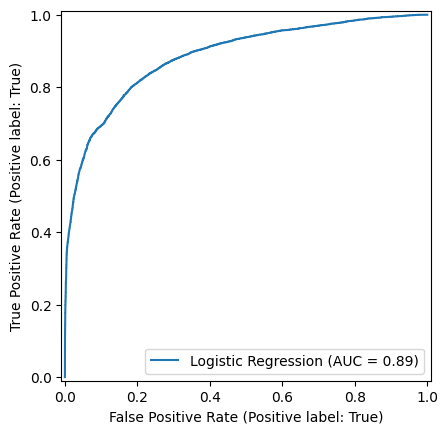

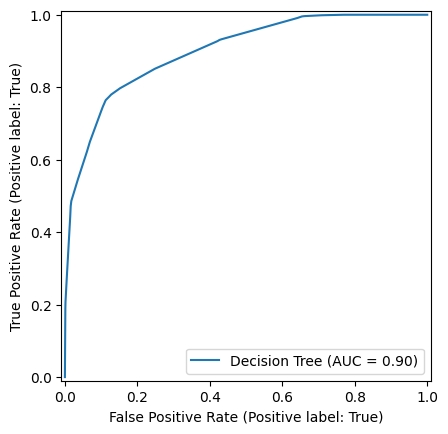

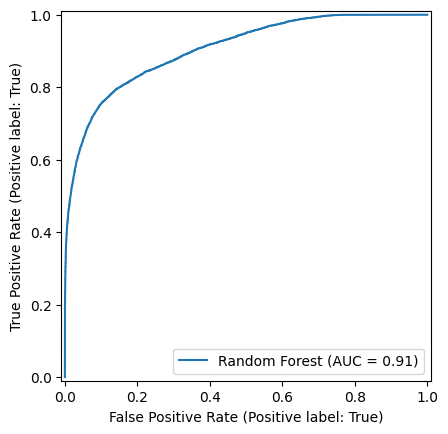

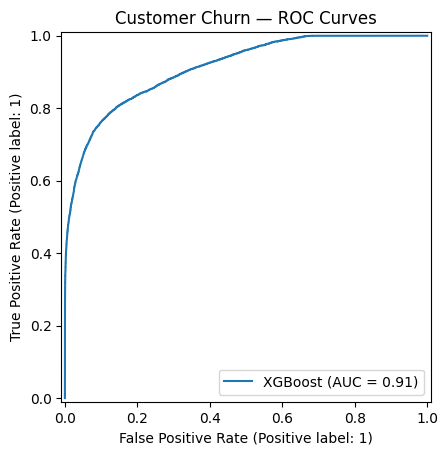

In [44]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("Customer Churn — ROC Curves")
plt.show()

Model selection:
Xgboost and Random forest have almost same score across f1, precision and accurcay. However, the aim of the customer churn is to predict the numbers of customer churn as possible. Xgboost has lower number of false negative meaning Customers that model predict that will not churn but will actually churn.

Saving model in using joblib

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBClassifier(n_estimators=300,
                            learning_rate=0.05,
                            max_depth=5,
                            min_child_weight=5,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None, ...))])

Comparing train_prediction churn to actual_churn in test_data

In [50]:
# Extract customer IDs and full names corresponding to the test set
test_customer_ids = df.loc[X_test.index, 'customer_id']
test_full_names = df.loc[X_test.index, 'full_name']

# Create test prediction DataFrame
test_prediction_dataframe = pd.DataFrame({
    'dataset': 'test',
    'customer_id': test_customer_ids,
    'full_name': test_full_names,
    'actual_churn': y_test,
    'predicted_churn':  xgboost_preds,
    'churn_probability': xgboost_probs
})
print(len(test_prediction_dataframe))
test_prediction_dataframe.head(50)

34046


,dataset,customer_id,full_name,actual_churn,predicted_churn,churn_probability
94585,test,1082746,Customer 82745,False,0,0.091759
37550,test,1499047,Customer 499046,False,0,0.091988
6668,test,1073188,Customer 73187,False,0,0.000421
53436,test,1243570,Customer 243569,False,0,0.065429
108512,test,1254089,Customer 254088,True,1,0.997685
24896,test,1105692,Customer 105691,True,1,0.967557
63859,test,1162000,Customer 161999,True,1,0.990135
80865,test,1211334,Customer 211333,True,1,0.914835
54121,test,1442973,Customer 442972,False,0,0.125980
15252,test,1058441,Customer 58440,False,0,0.061489


Exporting customer churn_prediction

In [51]:
from google.colab import files
outputfile ='customer_churn_prediction.csv'
test_prediction_dataframe.to_csv(outputfile, index=False)
files.download(outputfile)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# saving model using job lib
joblib.dump(pipeline, 'xgboost_pipeline_customer_churn_model.pkl')


['xgboost_pipeline_customer_churn_model.pkl']

In [ ]:

from google.colab import files
files.download('xgboost_pipeline_customer_churn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#  revenue loss prediction

In [ ]:
customer_features = (
    df
    .groupby('customer_id')
    .agg(
        total_orders=('order_date', 'count'),
        revenue=('total_spent', 'sum'),
        total_returns=('total_returns', 'sum'),
        avg_order_value=('total_spent', 'mean'),
        max_order_value=('total_spent', 'max'),
        customer_rating=('customer_rating', 'mean'),
        lifetime_value=('lifetime_value', 'max'),
        last_order_date=('order_date', 'max'),
        first_order_date=('order_date', 'min'),
        signup_date=('signup_date', 'first')
    )
    .reset_index()
)

In [ ]:
customer_features['customer_id'].value_counts()

,count
customer_id,
1499997,1
1000022,1
1000028,1
1000031,1
1000039,1
...,...
1000090,1
1000089,1
1000088,1


In [ ]:
customer_features['customer_id'].duplicated().sum()

np.int64(0)

In [ ]:
customer_features.head()

,customer_id,total_orders,revenue,total_returns,avg_order_value,max_order_value,customer_rating,lifetime_value,last_order_date,first_order_date,signup_date
0,1000022,1,1258512.45,10,1258512.45,1258512.45,3.0,2330461.08,2025-07-15,2025-07-15,2022-04-23
1,1000028,1,831464.16,1,831464.16,831464.16,1.0,2053033.25,2023-02-14,2023-02-14,2021-06-16
2,1000031,1,862738.37,3,862738.37,862738.37,1.0,2150987.15,2022-08-07,2022-08-07,2023-02-05
3,1000039,1,41041.12,5,41041.12,41041.12,4.0,56074.17,2022-09-21,2022-09-21,2024-06-07
4,1000049,1,181253.76,9,181253.76,181253.76,1.0,209463.79,2023-04-09,2023-04-09,2021-07-20


In [ ]:
X =[
    'total_orders',
    'total_returns',
    'avg_order_value',
    'max_order_value',

]
y= 'revenue'

In [ ]:
from sklearn.model_selection import train_test_split

# X is currently a list of column names, y is a string for the target column name
# We need to select the actual data from customer_features using these.
X_data = customer_features[X]
y_data = customer_features[y]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, # Pass the actual DataFrame for features
    y_data, # Pass the actual Series for the target
    test_size=0.30,
    random_state=42
)

print("Training:", X_train.shape)
print(X_data.head()) # Print the head of the actual feature data
print("Testing :", X_test.shape)

Training: (79438, 4)
   total_orders  total_returns  avg_order_value  max_order_value
0             1             10       1258512.45       1258512.45
1             1              1        831464.16        831464.16
2             1              3        862738.37        862738.37
3             1              5         41041.12         41041.12
4             1              9        181253.76        181253.76
Testing : (34046, 4)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_revenue = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_revenue.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [ ]:
import xgboost as xgb

xgb_revenue = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_revenue.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Comparing models

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

revenue_models = {
    'Linear Regression': linear_pipeline,
    'Random Forest': rf_revenue,
    'XGBoost': xgb_revenue
}

results = []

for name, model in revenue_models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

revenue_results = pd.DataFrame(results)

display(
    revenue_results.sort_values(
        'R2',
        ascending=False
    )
)

,Model,MAE,RMSE,R2
0,Linear Regression,1.008297e-10,1.300662e-10,1.000000
1,Random Forest,5.453619e+01,1.237598e+02,1.000000
2,XGBoost,1.415152e+03,2.950924e+03,0.999915


In [ ]:
overfitting_results = []

for name, model in revenue_models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    overfitting_results.append({
        'Model': name,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'R2 Gap': train_r2 - test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse
    })

overfitting_df = pd.DataFrame(overfitting_results)

display(overfitting_df)

,Model,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE
0,Linear Regression,1.000000,1.000000,0.000000e+00,1.289987e-10,1.300662e-10
1,Random Forest,1.000000,1.000000,6.621820e-08,9.183541e+01,1.237598e+02
2,XGBoost,0.999923,0.999915,8.156107e-06,2.785565e+03,2.950924e+03


In [ ]:
import pandas as pd

# Get customer IDs and full names corresponding to the revenue prediction test set.
# X_test and y_test for revenue prediction retain the original indices from customer_features.
# The 'customer_features' DataFrame contains the 'customer_id' and 'full_name' for these indices.
test_customer_data_for_revenue = customer_features.loc[y_test.index, ['customer_id']]

# Predict revenue using the chosen Linear Regression model (linear_pipeline).
predicted_revenue_linear = linear_pipeline.predict(X_test)

# Create the initial revenue prediction DataFrame
revenue_prediction_dataframe_base = pd.DataFrame({
    'customer_id': test_customer_data_for_revenue['customer_id'].values,
    'actual_revenue': y_test.values, # y_test is the actual revenue for the test set
    'predicted_revenue': predicted_revenue_linear
})

# Get unique churn status for each customer_id from the original 'df' DataFrame
customer_churn_status = df[['customer_id', 'churn']].drop_duplicates(subset=['customer_id'])

# Merge the churn status into the revenue prediction DataFrame
revenue_prediction_dataframe_with_churn = pd.merge(
    revenue_prediction_dataframe_base,
    customer_churn_status,
    on='customer_id',
    how='left'
)

# Filter for customers who actually churned ('churn == True')
# For churned customers, 'actual_revenue' represents the actual revenue loss.
churned_customers_revenue_loss = revenue_prediction_dataframe_with_churn[
    revenue_prediction_dataframe_with_churn['churn'] == True
]

# Display the head of the DataFrame for churned customers
print("Revenue Prediction for Churned Customers (Actual vs. Predicted Revenue Loss):")
display(churned_customers_revenue_loss.head())

# Save this DataFrame to a CSV file
output_filename = 'churned_customer_revenue_loss_comparison.csv'
churned_customers_revenue_loss.to_csv(output_filename, index=False)
print(f"\n'{output_filename}' created successfully.")

Revenue Prediction for Churned Customers (Actual vs. Predicted Revenue Loss):


,customer_id,actual_revenue,predicted_revenue,churn
7,1297305,310801.05,310801.05,True
11,1104217,194364.56,194364.56,True
13,1437927,21212.15,21212.15,True
14,1411648,103404.08,103404.08,True
17,1482704,87865.80,87865.80,True



'churned_customer_revenue_loss_comparison.csv' created successfully.


export churned_customer_revenue_loss_comparison

In [ ]:
from google.colab import files
files.download('churned_customer_revenue_loss_comparison.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Thanks for your time